In [ ]:
Context: https://github.com/JulenErcibengoaTekniker/IberFire/blob/main/notebooks/1.0-DatacubeVisualization/1.2-Visualisation-of-IberFire.ipynb

In [51]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import dask

ds = xr.open_dataset("IberFire.nc", chunks="auto")
print(ds)

<xarray.Dataset> Size: 731GB
Dimensions:                                        (y: 920, x: 1188, time: 6241)
Coordinates:
  * y                                              (y) float64 7kB 2.492e+06 ...
  * x                                              (x) float64 10kB 2.675e+06...
  * time                                           (time) datetime64[ns] 50kB ...
Data variables: (12/261)
    x_index                                        (y, x) uint16 2MB dask.array<chunksize=(920, 1188), meta=np.ndarray>
    y_index                                        (y, x) uint16 2MB dask.array<chunksize=(920, 1188), meta=np.ndarray>
    is_spain                                       (y, x) uint16 2MB dask.array<chunksize=(920, 1188), meta=np.ndarray>
    is_fire                                        (time, y, x) uint8 7GB dask.array<chunksize=(1562, 230, 298), meta=np.ndarray>
    is_near_fire                                   (time, y, x) uint8 7GB dask.array<chunksize=(1562, 230, 298), meta=

In [52]:
ds["is_spain"].sum()

<xarray.DataArray 'is_spain' ()> Size: 8B
dask.array<sum-aggregate, shape=(), dtype=uint64, chunksize=(), chunktype=numpy.ndarray>
Attributes:
    description:   Binary mask indicating the Spanish region: 1 for Spanish r...
    valid_values:  {0, 1}
    data_type:     uint8

In [53]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from matplotlib.colors import ListedColormap, BoundaryNorm
import ipywidgets as widgets
from datetime import datetime

cmap = ListedColormap([
    "#2c7bb6",  # Sea
    "#d9d9d9",  # Land
    "#66bd63",  # Spain
    "#d7191c",  # Fire
])

norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap.N)

legend_labels = ["Sea", "Land", "Spain", "Fire"]
legend_handles = [
    plt.Line2D([0], [0], marker="s", linestyle="",
               markerfacecolor=cmap(i), markersize=10)
    for i in range(4)
]

out = widgets.Output()

def plot_fire_at_date(date):
    with out:
        out.clear_output(wait=True)

        ds_t = ds.sel(time=np.datetime64(date))

        category = xr.zeros_like(ds_t["is_spain"], dtype=np.uint8)

        category = xr.where(ds_t["is_sea"] == 1, 0, category)
        category = xr.where(
            (ds_t["is_sea"] == 0) & (ds_t["is_spain"] == 0),
            1,
            category,
        )
        category = xr.where(
            (ds_t["is_spain"] == 1) & (ds_t["is_fire"] == 0),
            2,
            category,
        )
        category = xr.where(ds_t["is_fire"] == 1, 3, category)

        fig, ax = plt.subplots(figsize=(8, 8))
        ax.imshow(category, cmap=cmap, norm=norm)
        ax.set_title(f"Fire occurrence – {date}")
        ax.axis("off")

        ax.legend(
            legend_handles,
            legend_labels,
            loc="lower left",
            frameon=True
        )

        plt.show()


In [54]:
dates = ds.time.values.astype("datetime64[D]").astype(str)

slider = widgets.SelectionSlider(
    options=dates,
    value=dates[0],
    description="Date",
    layout=widgets.Layout(width="800px"),
    continuous_update=False
)

datepicker = widgets.DatePicker(
    description="Select date",
    value=datetime.strptime(dates[0], "%Y-%m-%d")
)


In [55]:
def on_slider_change(change):
    datepicker.value = datetime.strptime(change["new"], "%Y-%m-%d")
    plot_fire_at_date(change["new"])

def on_datepicker_change(change):
    date_str = change["new"].strftime("%Y-%m-%d")
    slider.value = date_str

slider.observe(on_slider_change, names="value")
datepicker.observe(on_datepicker_change, names="value")


In [56]:
plot_fire_at_date(dates[0])

widgets.VBox([
    slider,
    datepicker,
    out
])

In [139]:
import xarray as xr
import numpy as np
import pandas as pd

ds_2022 = ds.sel(time=slice("2021-12-27", "2022-12-31"))
days_before = [1, 2, 3, 4, 5]

fire = ds_2022["is_fire"]
fire_start = (fire == 1) & (fire.shift(time=1) == 0)

vars_to_analyze = [
    "LAI", "NDVI", "LST",
    "SWI_001", "SWI_005", "SWI_010", "SWI_020",
    "t2m_mean", "RH_mean", "surface_pressure_mean", 
    "total_precipitation_mean", "wind_speed_mean", "wind_direction_mean"
]

# ============================================================
# STEP 1: Load fire_start mask to memory ONCE
# ============================================================
print("Loading fire_start mask to memory...")
fire_start_vals = fire_start.values  # shape: (time, y, x)

# ============================================================
# STEP 2: Precompute ALL shifted masks ONCE (not per variable!)
# ============================================================
print("Precomputing shifted masks for all days...")
fire_start_shifted = {}
for d in days_before:
    # np.roll shifts along axis, but wraps around - we need to handle edges
    shifted = np.roll(fire_start_vals, d, axis=0)
    shifted[:d, :, :] = False  # First d timesteps have no valid "before" data
    fire_start_shifted[d] = shifted
    print(f"  Prepared mask for {d} day(s) before")

# ============================================================
# STEP 3: Load ALL variables to memory ONCE
# ============================================================
print("Loading all variables to memory...")
data_vars = {}
for var in vars_to_analyze:
    data_vars[var] = ds_2022[var].values
    print(f"  Loaded {var}: {data_vars[var].shape}")

# ============================================================
# STEP 4: Process with pure NumPy (no xarray overhead!)
# ============================================================
print("\nExtracting values...")
results = {}

for var in vars_to_analyze:
    var_data = data_vars[var]
    results[var] = {}
   
    for d in days_before:
        mask = fire_start_shifted[d]
       
        # Direct boolean indexing - much faster than .where()
        values = var_data[mask]
        values = values[~np.isnan(values)]
       
        results[var][d] = values.tolist()
   
    print(f"  {var}: {sum(len(results[var][d]) for d in days_before)} total values")

print("Done!")


Loading fire_start mask to memory...
Precomputing shifted masks for all days...
  Prepared mask for 1 day(s) before
  Prepared mask for 2 day(s) before
  Prepared mask for 3 day(s) before
  Prepared mask for 4 day(s) before
  Prepared mask for 5 day(s) before
Loading all variables to memory...
  Loaded LAI: (370, 920, 1188)
  Loaded NDVI: (370, 920, 1188)
  Loaded LST: (370, 920, 1188)
  Loaded SWI_001: (370, 920, 1188)
  Loaded SWI_005: (370, 920, 1188)
  Loaded SWI_010: (370, 920, 1188)
  Loaded SWI_020: (370, 920, 1188)
  Loaded t2m_mean: (370, 920, 1188)
  Loaded RH_mean: (370, 920, 1188)
  Loaded surface_pressure_mean: (370, 920, 1188)
  Loaded total_precipitation_mean: (370, 920, 1188)
  Loaded wind_speed_mean: (370, 920, 1188)
  Loaded wind_direction_mean: (370, 920, 1188)

Extracting values...
  LAI: 37670 total values
  NDVI: 37781 total values
  LST: 37755 total values
  SWI_001: 37630 total values
  SWI_005: 37630 total values
  SWI_010: 37630 total values
  SWI_020: 37630 t

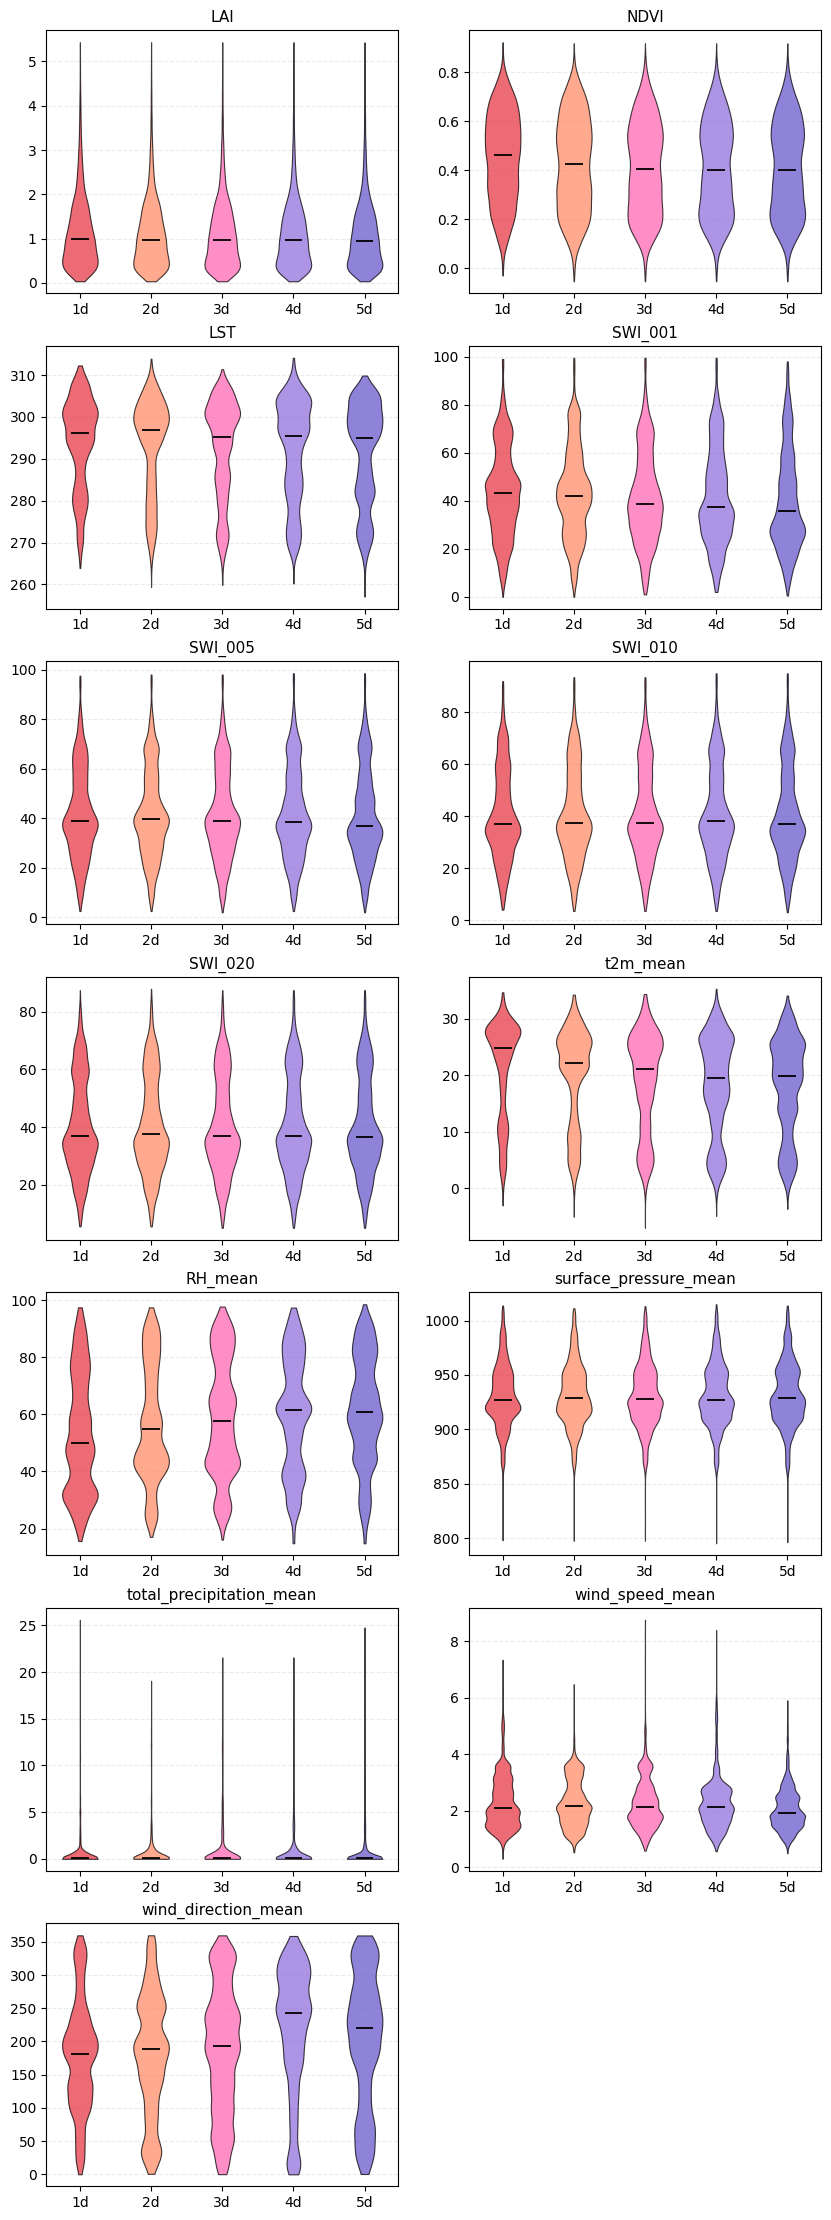

In [140]:
import matplotlib.pyplot as plt
import math

n_vars = len(vars_to_analyze)
n_cols = 2
n_rows = math.ceil(n_vars / n_cols)

day_colors = {
    5: "#6A5ACD",  # purple
    4: "#9370DB",  # lavender
    3: "#FF69B4",  # pink
    2: "#FF8C69",  # coral
    1: "#E63946",  # red
}

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(5 * n_cols, 4 * n_rows),
    squeeze=False
)

for i, var in enumerate(vars_to_analyze):
    row = i // n_cols
    col = i % n_cols
    ax = axes[row, col]

    data = [results[var][d] for d in days_before]

    parts = ax.violinplot(
        data,
        showmeans=False,
        showmedians=True,
        showextrema=False
    )

    # Color each violin
    for body, d in zip(parts["bodies"], days_before):
        body.set_facecolor(day_colors[d])
        body.set_edgecolor("black")
        body.set_alpha(0.75)
        body.set_linewidth(0.8)

    # Median styling
    parts["cmedians"].set_color("black")
    parts["cmedians"].set_linewidth(1.3)

    # Axis styling
    ax.set_title(var, fontsize=11, pad=6)
    ax.set_xticks(range(1, len(days_before) + 1))
    ax.set_xticklabels([f"{d}d" for d in days_before])
    ax.grid(axis="y", alpha=0.25, linestyle="--")
    ax.set_axisbelow(True)

for j in range(i + 1, n_rows * n_cols):
    fig.delaxes(axes[j // n_cols, j % n_cols])

In [119]:
code_labels = {
    0: "Nodata",
    1: "Andalucía",
    2: "Aragón",
    3: "Principado de Asturias",
    4: "Islas Baleares",
    5: "Canarias",
    6: "Cantabria",
    7: "Castilla y León",
    8: "Castilla - La Mancha",
    9: "Cataluña",
    10: "Comunidad Valenciana",
    11: "Extremadura",
    12: "Galicia",
    13: "Comunidad de Madrid",
    14: "Región de Murcia",
    15: "Comunidad Foral de Navarra",
    16: "País Vasco",
    17: "La Rioja",
    18: "Ceuta",
    19: "Melilla"
}

In [134]:
import numpy as np
import pandas as pd

ds_2022 = ds.sel(time=slice("2021-12-27", "2022-12-31"))

fire = ds_2022["is_fire"]

fire_start = (fire == 1) & (fire.shift(time=1) == 0)
fire_end   = (fire == 1) & (fire.shift(time=-1) == 0)

# Load all arrays to memory ONCE (avoids repeated xarray overhead)
print("Loading data to memory...")
fire_start_vals = fire_start.values  
fire_end_vals = fire_end.values
time_vals = ds_2022["time"].values

# Static variables (no time dimension)
aspect_vals = {i: ds_2022[f"aspect_{i}"].values for i in range(1, 9)}
elevation_vals = ds_2022["elevation_mean"].values
slope_vals = ds_2022["slope_mean"].values
roughness_vals = ds_2022["roughness_mean"].values

# Find fire pixels
has_fire_ever = fire_start_vals.any(axis=0)
fire_pixels = np.argwhere(has_fire_ever)

print(f"Processing {len(fire_pixels)} fire pixels...")

Loading data to memory...
Processing 7272 fire pixels...


In [135]:
records = []
for iy, ix in fire_pixels:
    starts = np.where(fire_start_vals[:, iy, ix])[0]
    ends = np.where(fire_end_vals[:, iy, ix])[0]
    
    for s, e in zip(starts, ends):
        records.append({
            "duration": e - s + 1,
            "y": iy,
            "x": ix,
            **{f"aspect_{i}": aspect_vals[i][iy, ix] for i in range(1, 9)},
            "elevation_mean": elevation_vals[iy, ix],
            "slope_mean": slope_vals[iy, ix],
            "roughness_mean": roughness_vals[iy, ix],
        })

In [136]:
df_fires = pd.DataFrame(records)

In [137]:
df_fires = pd.DataFrame(records)
aspect_cols = [f"aspect_{i}" for i in range(1, 9)]
df_fires["dominant_aspect"] = df_fires[aspect_cols].idxmax(axis=1)
df_fires["dominant_aspect"] = df_fires["dominant_aspect"].str.extract(r"(\d)").astype(int)

aspect_stats = (
    df_fires
    .groupby("dominant_aspect")["duration"]
    .agg(["mean", "count"])
    .reindex(range(1, 9))
)

print(aspect_stats)

                     mean  count
dominant_aspect                 
1                3.409501   1663
2                2.775610    410
3                2.789227    427
4                3.461099   1401
5                3.493865   1630
6                2.946835    395
7                2.686649    367
8                3.484634   1269


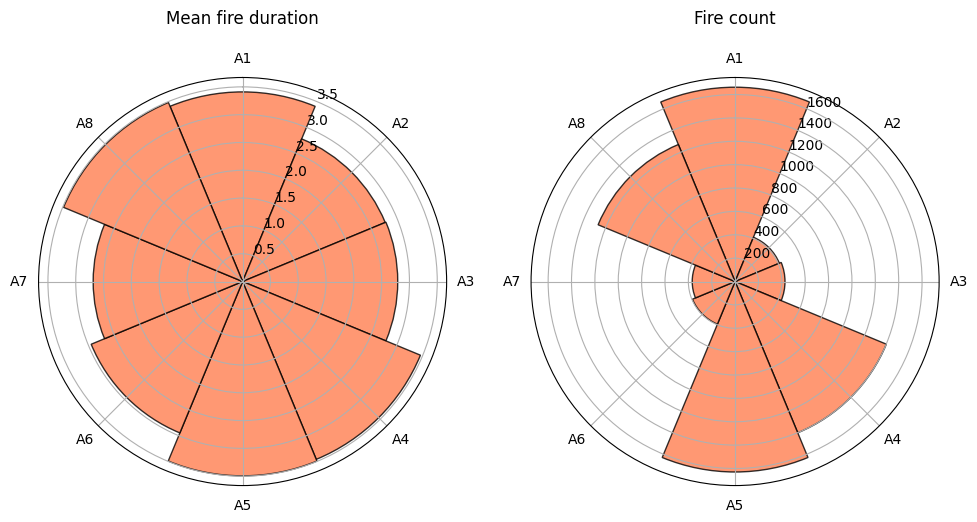

In [145]:
n_cols = 2
n_rows = 1

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(5 * n_cols, 5 * n_rows),
    squeeze=False,
    subplot_kw={'projection': 'polar'}  # ← Makes all subplots polar!
)

titles = {"mean": "Mean fire duration", "count": "Fire count"}

for i, kind in enumerate(["mean", "count"]):
    row = i // n_cols
    col = i % n_cols
    ax = axes[row, col]  # Now this IS a polar axis
   
    # NO new figure creation here!
   
    bars = ax.bar(
        angles,
        aspect_stats[kind],
        width=width,
        bottom=0,
        color="coral",
        edgecolor="black",
        alpha=0.8
    )
   
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.set_xticks(angles)
    ax.set_xticklabels([f"A{i}" for i in range(1, 9)])
   
    ax.set_title(titles[kind], pad=20)

plt.tight_layout()
plt.show()

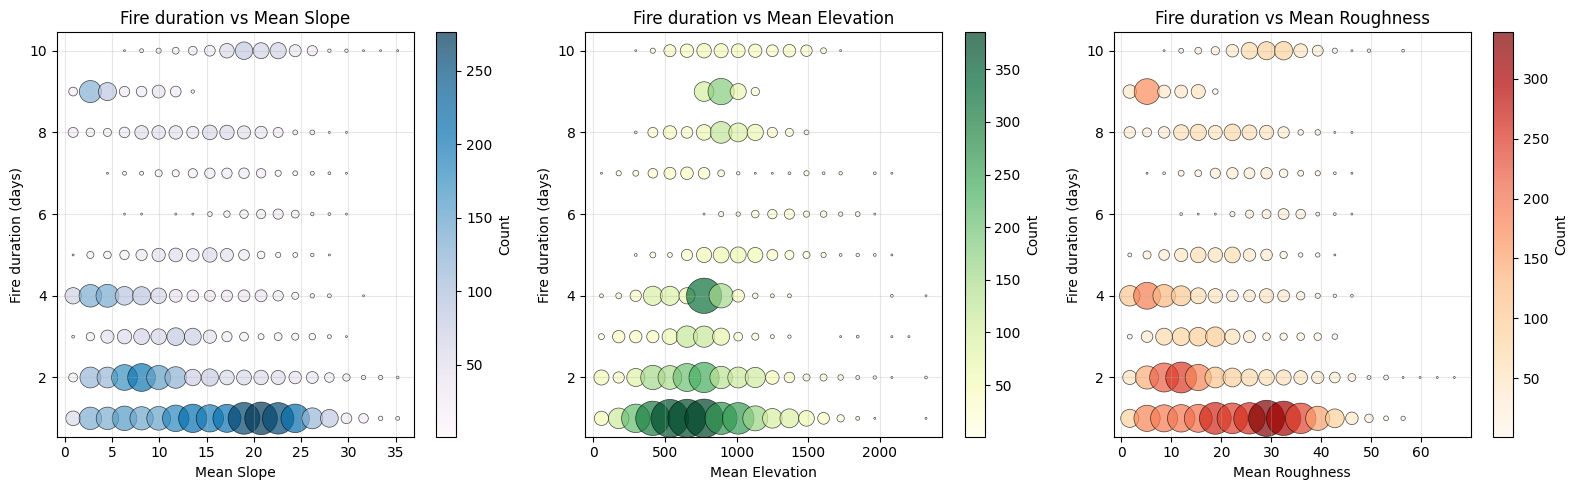

In [162]:
df_filtered = df_fires[df_fires["duration"] >= 0]

terrain_vars = [
    ("slope_mean", "Mean Slope", "PuBu"),
    ("elevation_mean", "Mean Elevation", "YlGn"),
    ("roughness_mean", "Mean Roughness", "OrRd")
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (var, label, color) in zip(axes, terrain_vars):
    # Bin the x variable and count occurrences
    df_temp = df_filtered[[var, "duration"]].dropna()
   
    # Create bins for the terrain variable
    df_temp["var_binned"] = pd.cut(df_temp[var], bins=20, labels=False)
    bin_edges = pd.cut(df_temp[var], bins=20, retbins=True)[1]
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
   
    # Group and count
    grouped = df_temp.groupby(["var_binned", "duration"]).size().reset_index(name="count")
    grouped["var_center"] = grouped["var_binned"].map(lambda i: bin_centers[int(i)] if pd.notna(i) else np.nan)
   
    # Plot bubbles
    scatter = ax.scatter(
        grouped["var_center"],
        grouped["duration"],
        s=grouped["count"] * 2,  # Scale factor for visibility
        c=grouped["count"],
        cmap=color,
        alpha=0.7,
        edgecolors="black",
        linewidths=0.5
    )
   
    ax.set_xlabel(label)
    ax.set_ylabel("Fire duration (days)")
    ax.set_title(f"Fire duration vs {label}")
    ax.grid(alpha=0.3)
   
    cb = plt.colorbar(scatter, ax=ax)
    cb.set_label("Count")

plt.tight_layout()
plt.show()